In [31]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

CONFIG = {
    "csv_path": "2026-rev-08-MD.csv",
    "p": 12,
    "split": (0.60, 0.20, 0.20),
    "n_hidden": 50,
    "lr": 0.01,
    "batch_size": 32,
    "max_epochs": 500,
    "patience": 30,
    "seeds": [0, 1, 2, 3, 4],
}

In [32]:
def fix_fred_century(dates):
    return np.array([
        d.replace(year=d.year - 100) if d.year >= 2059 else d
        for d in pd.to_datetime(dates)
    ])


def load_fred_multiseries(path):
    header = pd.read_csv(path, nrows=0).columns.tolist()
    transform_row = pd.read_csv(path, skiprows=1, nrows=1, header=None).iloc[0]
    df = pd.read_csv(path, skiprows=2, names=header)
    date_col = header[0]
    df[date_col] = pd.to_datetime(df[date_col], format="%m/%d/%y")
    df[date_col] = fix_fred_century(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    series_cols = header[1:]
    transform_codes = {col: int(transform_row[i + 1]) for i, col in enumerate(series_cols)}
    for col in series_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df, date_col, series_cols, transform_codes


def apply_fred_transform(series, code):
    """Apply a FRED-MD transformation code. Returns (transformed_series, date_offset).
    """
    x = np.asarray(series, dtype=np.float64)
    if code == 2:
        return np.diff(x).astype(np.float32), 1
    if code == 5:
        return np.diff(np.log(x)).astype(np.float32), 1
    if code == 6:
        return np.diff(np.log(x), n=2).astype(np.float32), 2
    raise ValueError(
        f"Transform code {code} is not implemented; expected 2, 5, or 6."
    )


def create_windows(series, p):
    X, y = [], []
    for t in range(p, len(series)):
        X.append(series[t - p:t])
        y.append(series[t])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def chronological_split(X, y, ratios=(0.60, 0.20, 0.20)):
    n = len(X)
    train_end = int(n * ratios[0])
    val_end = int(n * (ratios[0] + ratios[1]))
    return (
        X[:train_end], y[:train_end],
        X[train_end:val_end], y[train_end:val_end],
        X[val_end:], y[val_end:],
    )


def to_tensor(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    return X_t, y_t


def evaluate_mse(model, X_t, y_t, loss_fn):
    model.eval()
    with torch.no_grad():
        return loss_fn(model(X_t), y_t).item()


def fit_ar1(X_train, y_train):
    """OLS fit of z_{t+1} = a + b * z_t on the training windows.
    Returns np.array([a, b]).
    """
    z_t = X_train[:, -1].astype(np.float64)
    Z = np.column_stack([np.ones_like(z_t), z_t])
    coef, *_ = np.linalg.lstsq(Z, y_train.astype(np.float64), rcond=None)
    return coef


def ar1_predict(coef, X):
    return coef[0] + coef[1] * X[:, -1].astype(np.float64)


def ar1_mse(coef, X, y):
    return float(np.mean((y.astype(np.float64) - ar1_predict(coef, X)) ** 2))

In [33]:
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.affine_weight = nn.Parameter(torch.ones(num_features))
        self.affine_bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode):
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = x.std(dim=1, keepdim=True, unbiased=False).detach() + self.eps
            x = (x - self.mean) / self.std
            x = x * self.affine_weight + self.affine_bias
            return x
        elif mode == "denorm":
            x = (x - self.affine_bias) / self.affine_weight
            x = x * self.std + self.mean
            return x
        raise ValueError("mode must be 'norm' or 'denorm'")

In [34]:
class FullyConnectedNN(nn.Module):
    def __init__(self, p, n_hidden=50):
        super().__init__()
        self.revin = RevIN(num_features=1)
        self.hidden = nn.Linear(p, n_hidden)
        self.act = nn.ReLU()
        self.output = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x_norm = self.revin(x, mode="norm")
        x_flat = x_norm.squeeze(-1)
        h = self.act(self.hidden(x_flat))
        pred_norm = self.output(h).unsqueeze(1)
        pred = self.revin(pred_norm, mode="denorm")
        return pred.squeeze(1)

In [35]:
def train_model(X_train_t, y_train_t, X_val_t, y_val_t, config):
    model = FullyConnectedNN(p=config["p"], n_hidden=config["n_hidden"])
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=config["batch_size"],
        shuffle=True,
    )

    best_val = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(config["max_epochs"]):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_mse = evaluate_mse(model, X_val_t, y_val_t, loss_fn)
        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config["patience"]:
                break

    model.load_state_dict(best_state)
    return model, best_epoch, best_val

In [36]:
def run_series_pipeline(series_name, raw_values, dates, transform_code, config):
    raw = np.asarray(pd.to_numeric(raw_values, errors="coerce"), dtype=np.float64)
    dates = np.asarray(dates)

    filled = pd.Series(raw).interpolate(method="linear", limit_area="inside").values
    n_interpolated = int(np.isnan(raw).sum() - np.isnan(filled).sum())
    gap_dates = [str(pd.Timestamp(d).date())
                 for d in dates[np.isnan(raw) & ~np.isnan(filled)]]

    raw = filled

    transformed, date_offset = apply_fred_transform(raw, transform_code)
    dates = dates[date_offset:]
    series = transformed

    p = config["p"]
    X, y = create_windows(series, p)
    X_train, y_train, X_val, y_val, X_test, y_test = chronological_split(X, y, config["split"])

    # AR(1) baseline
    ar1_coef = fit_ar1(X_train, y_train)
    ar1_train_mse = ar1_mse(ar1_coef, X_train, y_train)
    ar1_val_mse = ar1_mse(ar1_coef, X_val, y_val)
    ar1_test_mse = ar1_mse(ar1_coef, X_test, y_test)
    ar1_test_pred = ar1_predict(ar1_coef, X_test)

    X_train_t, y_train_t = to_tensor(X_train, y_train)
    X_val_t, y_val_t = to_tensor(X_val, y_val)
    X_test_t, y_test_t = to_tensor(X_test, y_test)

    loss_fn = nn.MSELoss()

    seed_runs = []
    for seed in config["seeds"]:
        torch.manual_seed(seed)
        model, best_epoch, val_mse = train_model(
            X_train_t, y_train_t, X_val_t, y_val_t, config
        )
        seed_runs.append({
            "seed": seed,
            "best_epoch": best_epoch,
            "val_mse": val_mse,
            "train_mse": evaluate_mse(model, X_train_t, y_train_t, loss_fn),
            "test_mse": evaluate_mse(model, X_test_t, y_test_t, loss_fn),
            "model": model,
        })

    test_mses = np.array([s["test_mse"] for s in seed_runs])
    val_mses = np.array([s["val_mse"] for s in seed_runs])
    train_mses = np.array([s["train_mse"] for s in seed_runs])
    best_epochs = np.array([s["best_epoch"] for s in seed_runs])

    # Representative run for the forecast plots: median test MSE, not best.
    # Plotting the best seed would overstate performance.
    median_run = seed_runs[int(np.argsort(test_mses)[len(test_mses) // 2])]

    return {
        "series": series_name,
        "transform": transform_code,
        "n_train": len(y_train),
        "n_interpolated": n_interpolated,
        "interpolated_dates": ", ".join(gap_dates),
        "n_val": len(y_val),
        "n_test": len(y_test),
        "n_seeds": len(seed_runs),
        "best_epoch_mean": float(best_epochs.mean()),
        "train_mse_mean": float(train_mses.mean()),
        "val_mse_mean": float(val_mses.mean()),
        "test_mse_mean": float(test_mses.mean()),
        "test_mse_std": float(test_mses.std(ddof=1)),
        "test_mse_min": float(test_mses.min()),
        "test_mse_max": float(test_mses.max()),
        # AR(1) baseline
        "ar1_a": float(ar1_coef[0]),
        "ar1_b": float(ar1_coef[1]),
        "ar1_train_mse": ar1_train_mse,
        "ar1_val_mse": ar1_val_mse,
        "ar1_test_mse": ar1_test_mse,
        "test_mse_ratio": float(test_mses.mean()) / ar1_test_mse,
        "beats_ar1": float(test_mses.mean()) < ar1_test_mse,
        "n_seeds_beating_ar1": int((test_mses < ar1_test_mse).sum()),
        "ar1_test_pred": ar1_test_pred,
        "seed_runs": seed_runs,
        "model": median_run["model"],
        "median_seed": median_run["seed"],
        "y_test": y_test,
        "X_test": X_test,
        "dates": dates,
        "p": p,
        "val_end_idx": len(y_train) + len(y_val),
    }

In [37]:
df, date_col, series_cols, transform_codes = load_fred_multiseries(CONFIG["csv_path"])
print("Transform codes:", transform_codes)
print(df[[date_col] + series_cols].head())

results = []
for col in series_cols:
    print(f"\nTraining {col} (FRED code {transform_codes[col]})...")
    result = run_series_pipeline(
        col,
        df[col].values,
        df[date_col].values,
        transform_codes[col],
        CONFIG,
    )
    results.append(result)
    if result["n_interpolated"]:
        print(
            f"interpolated {result['n_interpolated']} missing level(s) at {result['interpolated_dates']}"
        )
    print(
        f"AR(1): a={result['ar1_a']:.4g}, b={result['ar1_b']:.4g}, test_mse={result['ar1_test_mse']:.6g}"
    )
    print(
        f"FCNN : test_mse={result['test_mse_mean']:.6g} ± {result['test_mse_std']:.3g} over {result['n_seeds']} seeds [{result['test_mse_min']:.6g}, {result['test_mse_max']:.6g}]"
    )
    print(
        f"ratio FCNN/AR(1) = {result['test_mse_ratio']:.3f} ({result['n_seeds_beating_ar1']}/{result['n_seeds']} seeds beat AR(1))"
    )

Transform codes: {'RPI': 5, 'UNRATE': 2, 'DPCERA3M086SBEA': 5, 'GS5': 2, 'CPIAUCSL': 6}
     sasdate       RPI  UNRATE  DPCERA3M086SBEA   GS5  CPIAUCSL
0 1959-01-01  2583.560     6.0           15.188  4.01     29.01
1 1959-02-01  2593.596     5.9           15.346  3.96     29.00
2 1959-03-01  2610.396     5.6           15.491  3.99     28.97
3 1959-04-01  2627.446     5.2           15.435  4.12     28.98
4 1959-05-01  2642.720     5.1           15.622  4.35     29.04

Training RPI (FRED code 5)...
AR(1): a=0.003287, b=-0.1001, test_mse=0.000487735
FCNN : test_mse=0.000557425 ± 2.84e-05 over 5 seeds [0.000510866, 0.000581114]
ratio FCNN/AR(1) = 1.143 (0/5 seeds beat AR(1))

Training UNRATE (FRED code 2)...
interpolated 1 missing level(s) at 2025-10-01
AR(1): a=-0.002141, b=0.06371, test_mse=0.781313
FCNN : test_mse=1.0133 ± 0.0218 over 5 seeds [0.981999, 1.03725]
ratio FCNN/AR(1) = 1.297 (0/5 seeds beat AR(1))

Training DPCERA3M086SBEA (FRED code 5)...
AR(1): a=0.003503, b=-0.1605, test

In [38]:
summary = pd.DataFrame([
    {
        "series": r["series"], "transform": r["transform"],
        "n_interpolated": r["n_interpolated"],
        "interpolated_dates": r["interpolated_dates"],
        "n_train": r["n_train"], "n_val": r["n_val"], "n_test": r["n_test"],
        "n_seeds": r["n_seeds"], "best_epoch_mean": r["best_epoch_mean"],
        "ar1_a": r["ar1_a"], "ar1_b": r["ar1_b"],
        "ar1_train_mse": r["ar1_train_mse"], "ar1_val_mse": r["ar1_val_mse"],
        "ar1_test_mse": r["ar1_test_mse"],
        "train_mse_mean": r["train_mse_mean"], "val_mse_mean": r["val_mse_mean"],
        "test_mse_mean": r["test_mse_mean"], "test_mse_std": r["test_mse_std"],
        "test_mse_min": r["test_mse_min"], "test_mse_max": r["test_mse_max"],
        "test_mse_ratio": r["test_mse_ratio"],
        "beats_ar1": r["beats_ar1"],
        "n_seeds_beating_ar1": r["n_seeds_beating_ar1"],
    }
    for r in results
])

per_seed = pd.DataFrame([
    {
        "series": r["series"], "transform": r["transform"], "seed": s["seed"],
        "best_epoch": s["best_epoch"], "train_mse": s["train_mse"],
        "val_mse": s["val_mse"], "test_mse": s["test_mse"],
        "ar1_test_mse": r["ar1_test_mse"],
        "test_mse_ratio": s["test_mse"] / r["ar1_test_mse"],
    }
    for r in results for s in r["seed_runs"]
])

summary

,series,transform,n_interpolated,interpolated_dates,n_train,n_val,n_test,n_seeds,best_epoch_mean,ar1_a,...,ar1_test_mse,train_mse_mean,val_mse_mean,test_mse_mean,test_mse_std,test_mse_min,test_mse_max,test_mse_ratio,beats_ar1,n_seeds_beating_ar1
0,RPI,5,0,,478,160,160,5,4.0,0.003287,...,0.000488,0.000017,0.000060,0.000557,2.844165e-05,0.000511,0.000581,1.142886,False,0
1,UNRATE,2,1,2025-10-01,478,160,160,5,1.6,-0.002141,...,0.781313,0.028839,0.022931,1.013305,2.182435e-02,0.981999,1.037250,1.296926,False,0
2,DPCERA3M086SBEA,5,0,,478,160,160,5,2.4,0.003503,...,0.000206,0.000029,0.000015,0.000222,6.696854e-06,0.000216,0.000233,1.079125,False,0
3,GS5,2,0,,478,160,160,5,0.2,0.001437,...,0.034762,0.108317,0.061446,0.038887,9.590227e-04,0.038260,0.040515,1.118686,False,0
4,CPIAUCSL,6,1,2025-10-01,478,159,160,5,2.4,0.000005,...,0.000007,0.000004,0.000013,0.000007,2.455328e-07,0.000007,0.000007,0.990083,True,3


In [39]:
run_summary = per_seed.copy()
for key, val in CONFIG.items():
    if key == "seeds":
        continue                       # already a per-row column
    run_summary[key] = str(val) if isinstance(val, (tuple, list)) else val

run_summary["run_id"] = (
    f"p{CONFIG['p']}_h{CONFIG['n_hidden']}_lr{CONFIG['lr']}_bs{CONFIG['batch_size']}"
)

log_path = "experiment_log.csv"
if os.path.exists(log_path):
    old = pd.read_csv(log_path)
    combined = pd.concat([old, run_summary], ignore_index=True)
else:
    combined = run_summary

combined.to_csv(log_path, index=False)
print(f"Saved to {log_path} ({len(combined)} total rows)")
combined.tail(len(run_summary))

Saved to experiment_log.csv (25 total rows)


,series,transform,seed,best_epoch,train_mse,val_mse,test_mse,ar1_test_mse,test_mse_ratio,csv_path,p,split,n_hidden,lr,batch_size,max_epochs,patience,run_id
0,RPI,5,0,5,0.000016,0.000060,0.000578,0.000488,1.185515,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
1,RPI,5,1,4,0.000017,0.000061,0.000564,0.000488,1.157342,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
2,RPI,5,2,4,0.000017,0.000061,0.000581,0.000488,1.191455,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
3,RPI,5,3,4,0.000017,0.000061,0.000552,0.000488,1.132690,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
4,RPI,5,4,3,0.000017,0.000059,0.000511,0.000488,1.047425,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
5,UNRATE,2,0,2,0.028413,0.023218,1.037250,0.781313,1.327573,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
6,UNRATE,2,1,1,0.029564,0.023101,1.025115,0.781313,1.312042,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
7,UNRATE,2,2,0,0.030861,0.022639,0.981999,0.781313,1.256858,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
8,UNRATE,2,3,3,0.027675,0.023466,1.001020,0.781313,1.281203,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32
9,UNRATE,2,4,2,0.027681,0.022230,1.021140,0.781313,1.306954,2026-rev-08-MD.csv,12,"(0.6, 0.2, 0.2)",50,0.01,32,500,30,p12_h50_lr0.01_bs32


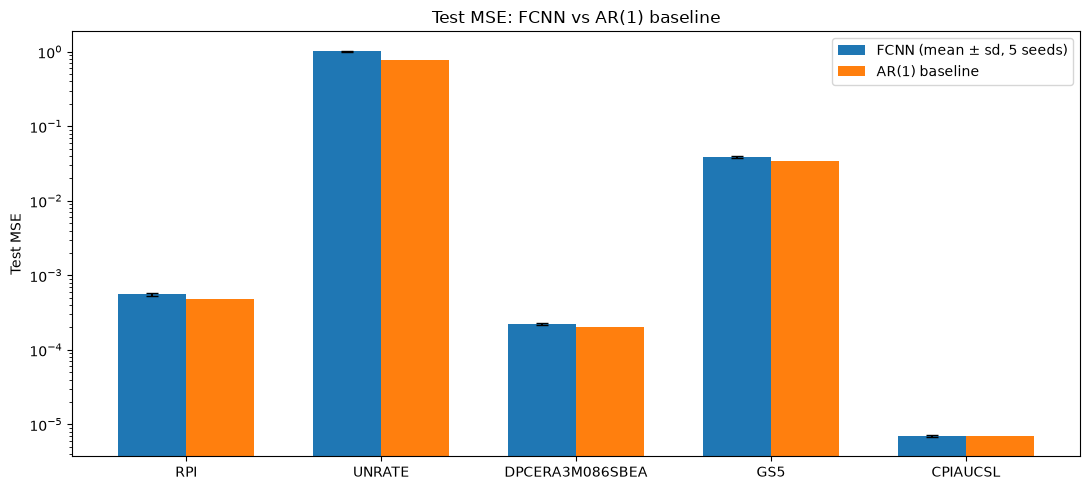

In [40]:
x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    x - width / 2,
    [r["test_mse_mean"] for r in results],
    width,
    yerr=[r["test_mse_std"] for r in results],
    capsize=4,
    label=f"FCNN (mean ± sd, {len(CONFIG['seeds'])} seeds)",
)
ax.bar(
    x + width / 2,
    [r["ar1_test_mse"] for r in results],
    width,
    label="AR(1) baseline",
)

ax.set_xticks(x)
ax.set_xticklabels([r["series"] for r in results])
ax.set_ylabel("Test MSE")
ax.set_yscale("log")  # series live on very different scales after transformation
ax.set_title("Test MSE: FCNN vs AR(1) baseline")
ax.legend()
plt.tight_layout()
plt.show()

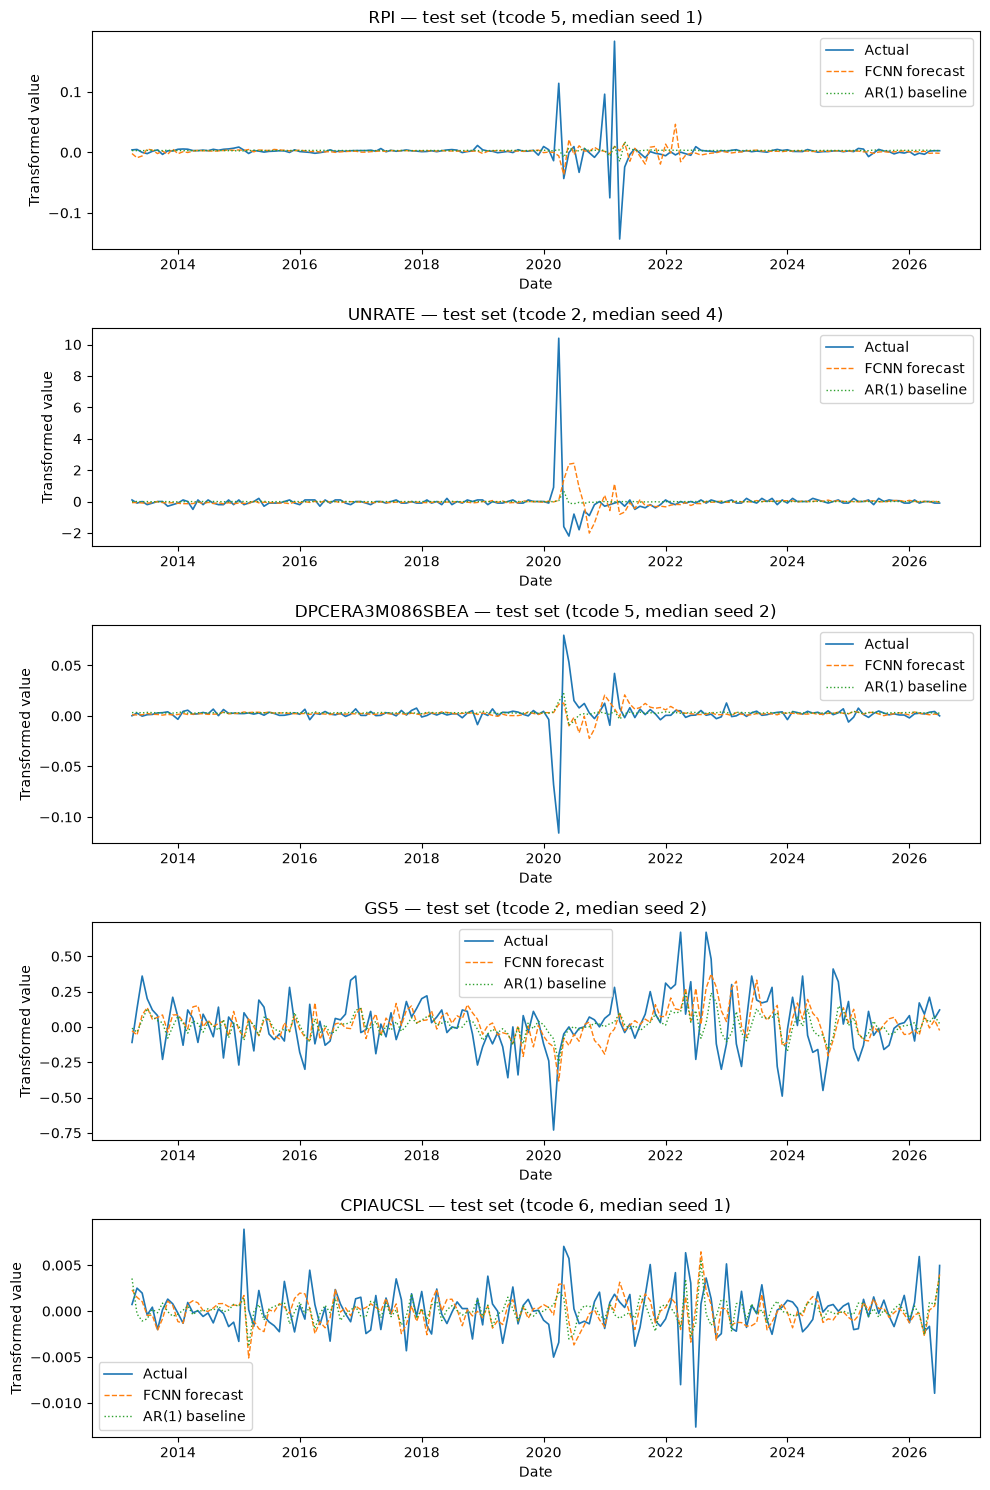

In [41]:
fig, axes = plt.subplots(len(results), 1, figsize=(10, 3 * len(results)), sharex=False)
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    model = r["model"]
    X_test_t, _ = to_tensor(r["X_test"], r["y_test"])
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t).squeeze(-1).numpy()

    test_dates = r["dates"][r["p"] + r["val_end_idx"]:]
    ax.plot(test_dates, r["y_test"], label="Actual", linewidth=1.2)
    ax.plot(test_dates, test_pred, label="FCNN forecast", linestyle="--", linewidth=1.0)
    ax.plot(test_dates, r["ar1_test_pred"], label="AR(1) baseline",
            linestyle=":", linewidth=1.0)
    ax.set_title(
        f"{r['series']} — test set (tcode {r['transform']}, median seed {r['median_seed']})"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Transformed value")
    ax.legend()

plt.tight_layout()
plt.show()